#### _Exploratory Data Analysis_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sqlalchemy import create_engine

In [ ]:
DB_USER = 'root'
DB_PW = 'your_password'
DB_HOST = 'localhost'
DB_PORT = '3306'
DB_NAME = 'saas_conversion'

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PW}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [3]:
df_accounts = pd.read_sql_query("SELECT * FROM accounts", engine)
df_subscriptions = pd.read_sql_query("SELECT * FROM subscriptions", engine)
df_feature_usage = pd.read_sql_query("SELECT * FROM feature_usage", engine)
df_support_tickets = pd.read_sql_query("SELECT * FROM support_tickets", engine)
master_analytics = pd.read_sql_query("SELECT * FROM master_analytics", engine)

dataframes = {
    'df_accounts': df_accounts,
    'df_subscriptions': df_subscriptions,
    'df_feature_usage': df_feature_usage,
    'df_support_tickets': df_support_tickets,
    'master_analytics': master_analytics
}

for name, df in dataframes.items():
    print(f"--- Table: {name} ---")
    print(f"Shape (Rows, Columns): {df.shape}")
    display(df.head(3))
    print("-"*50)

--- Table: df_accounts ---
Shape (Rows, Columns): (500, 7)


,account_id,industry,signup_date,referral_source,plan_tier,seats,is_trial
0,A-00bed1,Cybersecurity,2023-11-14,ads,Basic,28,1
1,A-00cac8,HealthTech,2023-09-15,organic,Enterprise,8,1
2,A-0158bb,FinTech,2024-05-22,partner,Basic,5,0


--------------------------------------------------
--- Table: df_subscriptions ---
Shape (Rows, Columns): (5000, 7)


,subscription_id,account_id,start_date,plan_tier,mrr_amount,is_trial,billing_frequency
0,S-001561,A-1b7577,2024-12-12,Enterprise,1194,0,annual
1,S-0027d3,A-e693b6,2024-05-04,Basic,1045,0,annual
2,S-003647,A-e36807,2024-12-23,Enterprise,1791,0,monthly


--------------------------------------------------
--- Table: df_feature_usage ---
Shape (Rows, Columns): (11802, 7)


...

--------------------------------------------------
--- Table: df_support_tickets ---
Shape (Rows, Columns): (923, 5)


,account_id,submitted_at,resolution_time_hours,first_response_time_minutes,satisfaction_score
0,A-e43bf7,2024-07-08,27.0,144,NaN
1,A-0f3e88,2024-10-17,19.0,93,4.0
2,A-4c56c9,2024-09-08,47.0,126,5.0


--------------------------------------------------
--- Table: master_analytics ---
Shape (Rows, Columns): (500, 16)


,account_id,industry,signup_date,referral_source,plan_tier,seats,converted_to_paid,total_clicks,total_duration_mins,total_errors_encountered,distinct_features_tried,active_days_count,tickets_raised_count,avg_response_time_mins,avg_csat_score,skipped_surveys_count
0,A-00bed1,Cybersecurity,2023-11-14,ads,Basic,28,1,19,16.9000,0,2,2,0,-1.0,-1.0,0
1,A-00cac8,HealthTech,2023-09-15,organic,Enterprise,8,0,13,25.1333,0,1,1,0,-1.0,-1.0,0
2,A-0158bb,FinTech,2024-05-22,partner,Basic,5,0,7,38.7333,0,1,1,0,-1.0,-1.0,0


--------------------------------------------------


##### _Descriptive Statistics, Outliers, and Correlations_

In [4]:
df_accounts.describe(include="all")

,account_id,industry,signup_date,referral_source,plan_tier,seats,is_trial
count,500,500,500,500,500,500.000000,500.000000
unique,500,5,NaN,5,3,NaN,NaN
top,A-00bed1,DevTools,NaN,organic,Pro,NaN,NaN
freq,1,113,NaN,114,178,NaN,NaN
mean,NaN,NaN,2024-01-27 06:34:33.600000256,NaN,NaN,20.560000,0.194000
min,NaN,NaN,2023-01-02 00:00:00,NaN,NaN,1.000000,0.000000
25%,NaN,NaN,2023-08-06 18:00:00,NaN,NaN,5.000000,0.000000
50%,NaN,NaN,2024-02-21 00:00:00,NaN,NaN,15.000000,0.000000
75%,NaN,NaN,2024-08-04 06:00:00,NaN,NaN,28.000000,0.000000
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,163.000000,1.000000


In [5]:
target_cols = ["industry","referral_source","plan_tier"]
for col in target_cols:
    print(col)
    print(df_accounts[col].unique())
    print("-"*50)

industry
['Cybersecurity' 'HealthTech' 'FinTech' 'EdTech' 'DevTools']
--------------------------------------------------
referral_source
['ads' 'organic' 'partner' 'event' 'other']
--------------------------------------------------
plan_tier
['Basic' 'Enterprise' 'Pro']
--------------------------------------------------


In [6]:
df_subscriptions.describe(include="all")

,subscription_id,account_id,start_date,plan_tier,mrr_amount,is_trial,billing_frequency
count,5000,5000,5000,5000,5000.000000,5000.000000,5000
unique,5000,500,NaN,3,NaN,NaN,2
top,S-001561,A-726cfa,NaN,Enterprise,NaN,NaN,monthly
freq,1,19,NaN,1723,NaN,NaN,2539
mean,NaN,NaN,2024-07-14 01:49:43.680000256,NaN,2267.749400,0.155600,NaN
min,NaN,NaN,2023-01-09 00:00:00,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,2024-04-17 18:00:00,NaN,285.000000,0.000000,NaN
50%,NaN,NaN,2024-09-01 00:00:00,NaN,931.000000,0.000000,NaN
75%,NaN,NaN,2024-11-17 00:00:00,NaN,2786.000000,0.000000,NaN
max,NaN,NaN,2024-12-31 00:00:00,NaN,33830.000000,1.000000,NaN


In [7]:
target_cols = ["plan_tier","billing_frequency"]
for col in target_cols:
    print(col)
    print(df_subscriptions[col].unique())
    print("-"*50)

plan_tier
['Enterprise' 'Basic' 'Pro']
--------------------------------------------------
billing_frequency
['annual' 'monthly']
--------------------------------------------------


In [8]:
df_feature_usage.describe(include="all")

,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
count,11802,11802,11802,11802.000000,11802.000000,11802.000000,11802.000000
unique,3906,NaN,40,NaN,NaN,NaN,NaN
top,S-02b754,NaN,feature_32,NaN,NaN,NaN,NaN
freq,14,NaN,331,NaN,NaN,NaN,NaN
mean,NaN,2024-05-09 08:30:59.481443584,NaN,10.002118,3019.328334,0.548043,0.098373
min,NaN,2023-01-06 00:00:00,NaN,1.000000,9.000000,0.000000,0.000000
25%,NaN,2024-01-13 00:00:00,NaN,8.000000,1330.000000,0.000000,0.000000
50%,NaN,2024-06-11 00:00:00,NaN,10.000000,2724.000000,0.000000,0.000000
75%,NaN,2024-10-02 00:00:00,NaN,12.000000,4356.000000,1.000000,0.000000
max,NaN,2024-12-31 00:00:00,NaN,23.000000,12696.000000,7.000000,1.000000


In [9]:
print("feature_name")
print(df_feature_usage["feature_name"].unique())

feature_name
['feature_5' 'feature_3' 'feature_12' 'feature_14' 'feature_36'
 'feature_35' 'feature_4' 'feature_40' 'feature_37' 'feature_20'
 'feature_18' 'feature_21' 'feature_19' 'feature_39' 'feature_38'
 'feature_22' 'feature_16' 'feature_24' 'feature_10' 'feature_27'
 'feature_1' 'feature_30' 'feature_34' 'feature_32' 'feature_7'
 'feature_6' 'feature_31' 'feature_15' 'feature_13' 'feature_11'
 'feature_26' 'feature_33' 'feature_28' 'feature_9' 'feature_25'
 'feature_8' 'feature_2' 'feature_29' 'feature_23' 'feature_17']


In [10]:
df_support_tickets.describe(include="all")

,account_id,submitted_at,resolution_time_hours,first_response_time_minutes,satisfaction_score
count,923,923,923.000000,923.000000,551.000000
unique,374,NaN,NaN,NaN,NaN
top,A-ed510f,NaN,NaN,NaN,NaN
freq,9,NaN,NaN,NaN,NaN
mean,NaN,2024-05-15 22:18:35.492957696,35.510293,89.684724,3.960073
min,NaN,2023-01-25 00:00:00,1.000000,1.000000,3.000000
25%,NaN,2024-01-22 12:00:00,17.000000,45.500000,3.000000
50%,NaN,2024-06-23 00:00:00,35.000000,90.000000,4.000000
75%,NaN,2024-10-09 00:00:00,54.000000,132.000000,5.000000
max,NaN,2024-12-31 00:00:00,72.000000,180.000000,5.000000


In [11]:
master_analytics.describe(include='all')

,account_id,industry,signup_date,referral_source,plan_tier,seats,converted_to_paid,total_clicks,total_duration_mins,total_errors_encountered,distinct_features_tried,active_days_count,tickets_raised_count,avg_response_time_mins,avg_csat_score,skipped_surveys_count
count,500,500,500,500,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
unique,500,5,NaN,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,A-00bed1,DevTools,NaN,organic,Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,113,NaN,114,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-01-27 06:34:33.600000256,NaN,NaN,20.560000,0.316000,4.526000,22.030728,0.228000,0.456000,0.450000,0.072000,4.369000,-0.774000,0.02000
min,NaN,NaN,2023-01-02 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.00000
25%,NaN,NaN,2023-08-06 18:00:00,NaN,NaN,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.00000
50%,NaN,NaN,2024-02-21 00:00:00,NaN,NaN,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.00000
75%,NaN,NaN,2024-08-04 06:00:00,NaN,NaN,28.000000,1.000000,8.250000,24.825000,0.000000,1.000000,1.000000,0.000000,-1.000000,-1.000000,0.00000
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,163.000000,1.000000,48.000000,300.100000,7.000000,4.000000,4.000000,2.000000,178.000000,5.000000,1.00000


- Since the median for both clicks and duration is exactly 0, it means more than 50% of trial signups have zero log activity in their first week. Most users register and immediately abandoned the product.

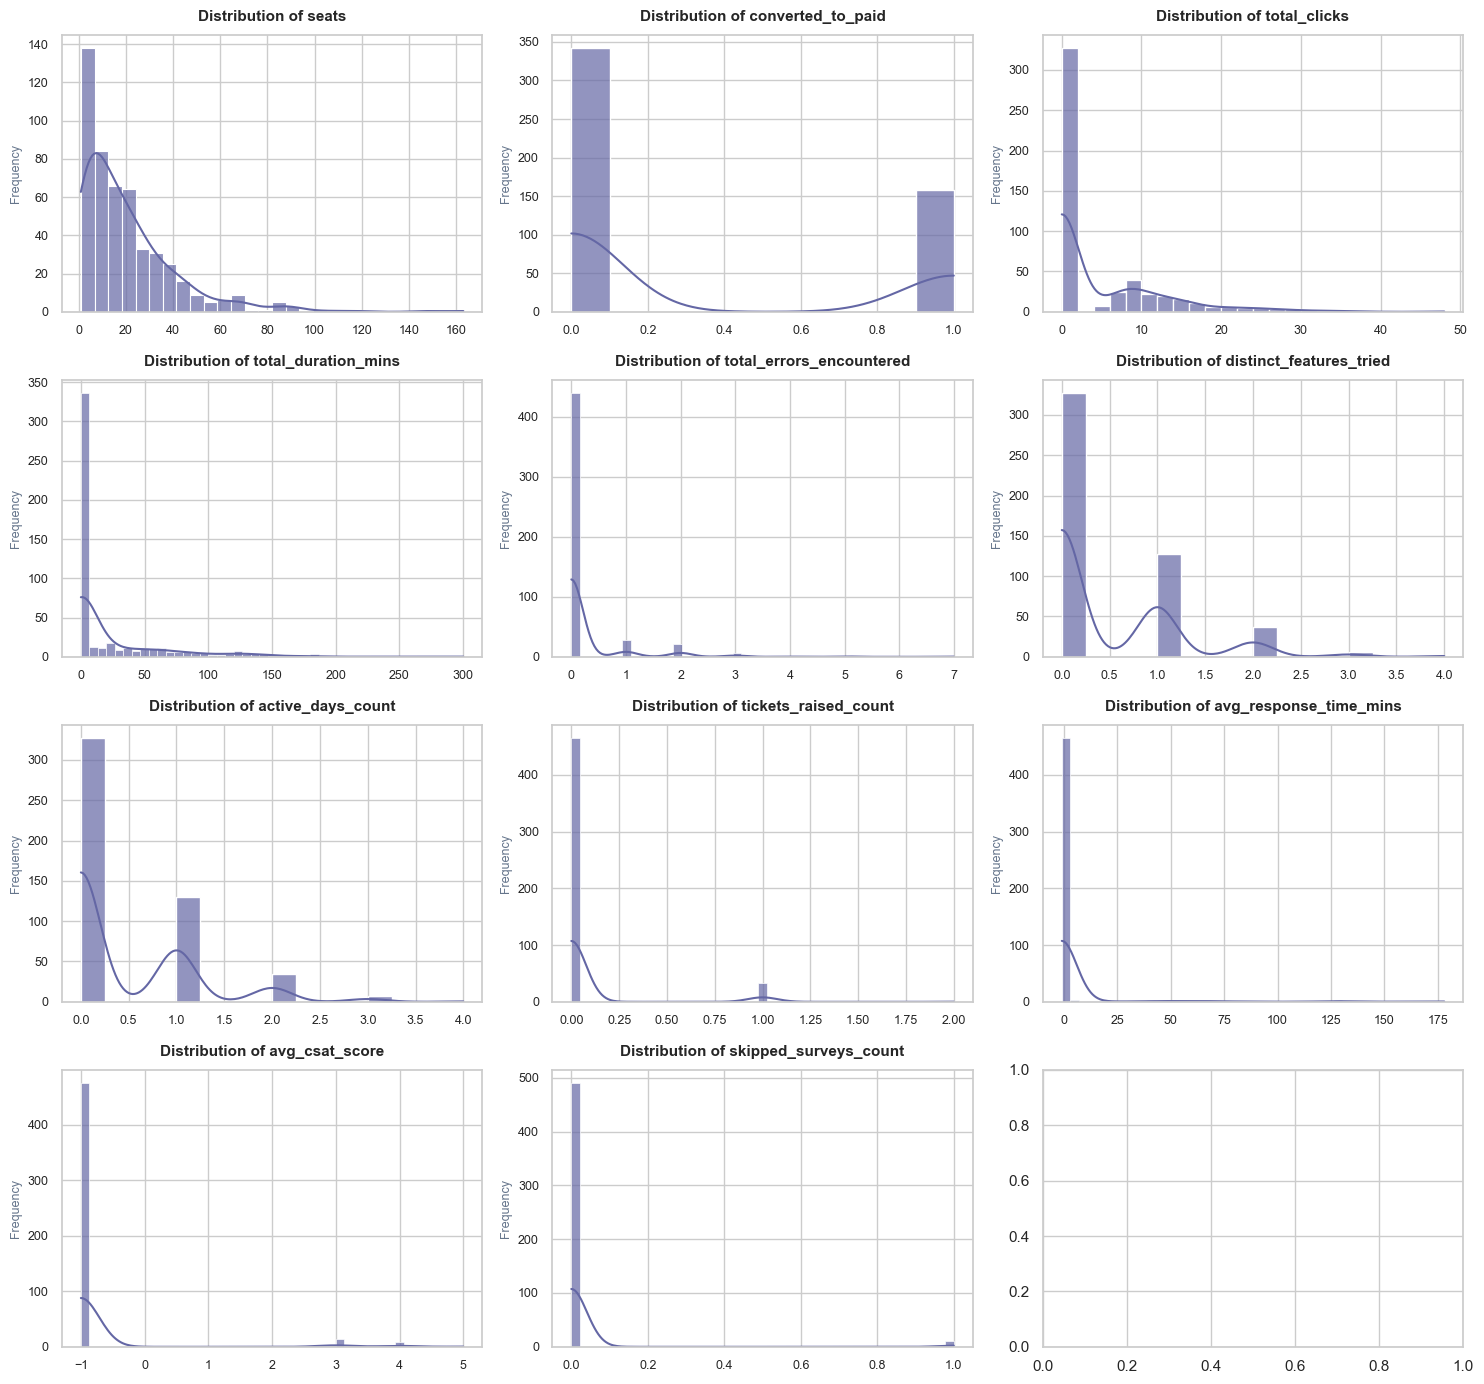

In [12]:
# Distribution plots for numerical colums
num_cols = master_analytics.select_dtypes(include=np.number).columns

# Setup the dynamic subplot grid based on the number of features
num_features = len(num_cols)
cols = 3
rows = (num_features + cols - 1) // cols

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=master_analytics,
        x=col,
        kde=True,
        ax=axes[i],
        color='#6467a5',
        edgecolor='white',
        alpha=0.7
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=9, color='#64748b')
    axes[i].tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()

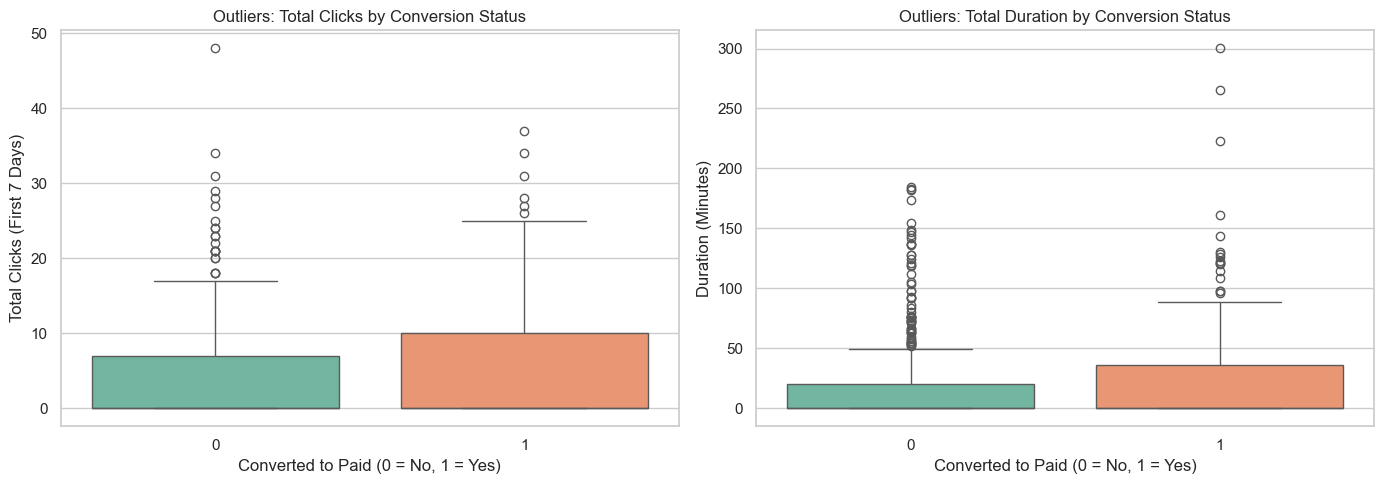

In [13]:
# Checking outliers

plt.figure(figsize=(14,5))

# Boxplot for total clicks
plt.subplot(1,2,1)
sns.boxplot(data=master_analytics, x='converted_to_paid', y='total_clicks', palette='Set2', hue='converted_to_paid', legend=False)
plt.title("Outliers: Total Clicks by Conversion Status")
plt.xlabel('Converted to Paid (0 = No, 1 = Yes)')
plt.ylabel('Total Clicks (First 7 Days)')

# Boxplot for total duration
plt.subplot(1,2,2)
sns.boxplot(data=master_analytics, x='converted_to_paid', y='total_duration_mins', palette='Set2', hue='converted_to_paid', legend=False)
plt.title("Outliers: Total Duration by Conversion Status")
plt.xlabel('Converted to Paid (0 = No, 1 = Yes)')
plt.ylabel('Duration (Minutes)')

plt.tight_layout()
plt.show()

- We have non-converters who logged up to 50 clicks and 200 minutes (3.3 hours) of usage in their first week, yet chose not to pay. This directly supports our hypothesis that they get a massive amount of free value during the trial to finish a one-time task and had no reason to subscribe.

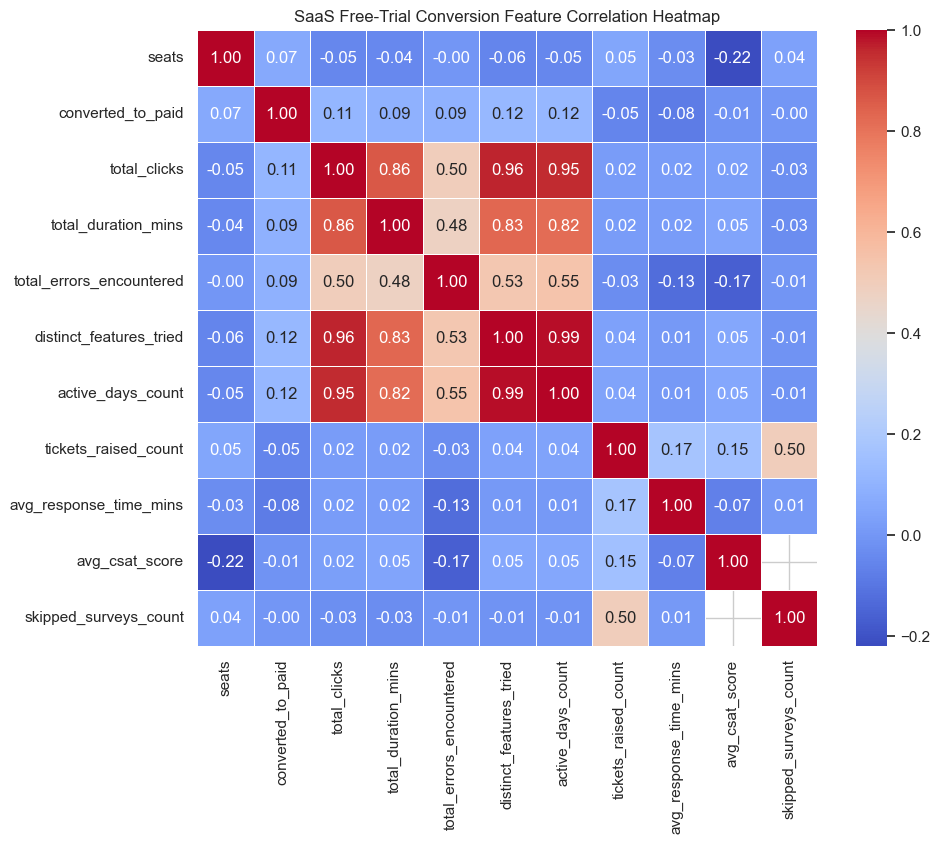

In [14]:
# Correlation

master_corr = master_analytics.copy()
master_corr['avg_response_time_mins'] = master_corr['avg_response_time_mins'].replace(-1, np.nan)
master_corr['avg_csat_score'] = master_corr['avg_csat_score'].replace(-1, np.nan)

numerical_columns = master_corr.select_dtypes(include=np.number).columns

corr_matrix = master_corr[numerical_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('SaaS Free-Trial Conversion Feature Correlation Heatmap')
plt.show()

- **total_clicks** and **total_duration_mins** are almost perfectly correlated. Keeping both would cause redundancy.
- A negative correlation between **converted_to_paid** and **avg_csat_score** means that users who give lower satisfaction scores are actually more likely to convert. This indicates that users who are interested in software ignore minor errors and they still buy because they need it.
- A high correlation between **tickets_raised_counts** and **skipped_surveys_count** means the more tickets a user submits, the more they skip the feedback survey, this directly indicates that consumers feel overwhelmed by excessive or irrelevant brand messages.

##### _Research Questions_ 

Product Engagement & The "Feature Trap" Questions

In [15]:
query1 = '''
    SELECT 
        converted_to_paid,
        COUNT(account_id) as total_accounts,
        CONCAT(
            ROUND((COUNT(account_id) * 100.0) / SUM(COUNT(account_id)) OVER (), 2), '%%'
        ) AS conversion_percentage
    FROM master_analytics
    GROUP BY converted_to_paid;  
'''
account_conversion = pd.read_sql_query(query1, con=engine)
display(account_conversion)

,converted_to_paid,total_accounts,conversion_percentage
0,1,158,31.60%
1,0,342,68.40%


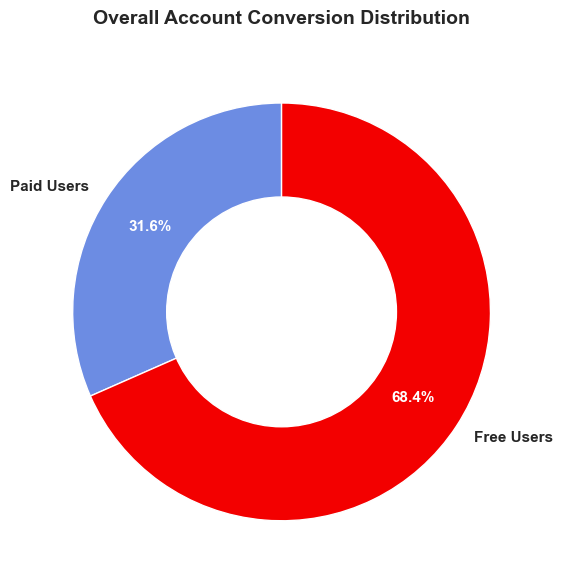

In [16]:
sns.set_theme(style='white')
plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    account_conversion['total_accounts'], 
    labels=[ 'Paid Users', 'Free Users'], 
    colors=["#6c8ce3", "#f30000"],
    autopct='%1.1f%%',
    startangle=90,    
    pctdistance=0.75,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

autotexts[0].set_color('white')
autotexts[1].set_color('white')

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Account Conversion Distribution', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
query2 = '''
    SELECT    
        converted_to_paid,
        ROUND(AVG(total_clicks)) as average_total_clicks,
        ROUND(AVG(total_duration_mins),2) as average_total_duration_mins
    FROM master_analytics
    GROUP BY converted_to_paid;
'''
engagement_stats = pd.read_sql_query(query2, con=engine)
display(engagement_stats)

,converted_to_paid,average_total_clicks,average_total_duration_mins
0,1,6.0,28.00
1,0,4.0,19.27


In [18]:
query3 = '''
    SELECT 
        m.converted_to_paid,
        COUNT(f.feature_name) AS feature_usage_count,
        ROUND(
            (COUNT(f.feature_name) * 100.0) / SUM(COUNT(*)) OVER(), 
            2
        ) AS feature_usage_percentage
    FROM feature_usage AS f
    INNER JOIN subscriptions AS s
        ON f.subscription_id = s.subscription_id
    INNER JOIN master_analytics AS m 
        ON m.account_id = s.account_id
    GROUP BY m.converted_to_paid
    ORDER BY m.converted_to_paid ASC;
'''

total_feature_usage = pd.read_sql_query(query3, con=engine)
display(total_feature_usage)

,converted_to_paid,feature_usage_count,feature_usage_percentage
0,0,9117,77.25
1,1,2685,22.75


In [19]:
query4 = '''
SELECT 
    distinct_features_tried,
    COUNT(account_id) as total_accounts,
    SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) as successful_conversions,
    ROUND((SUM(converted_to_paid) * 100 / COUNT(account_id)), 2) as conversion_rate_pct
FROM master_analytics
GROUP BY distinct_features_tried
ORDER BY distinct_features_tried DESC;
'''

features_tried_conversion = pd.read_sql(query4, con=engine)
display(features_tried_conversion)

,distinct_features_tried,total_accounts,successful_conversions,conversion_rate_pct
0,4,2,1.0,50.00
1,3,6,2.0,33.33
2,2,37,15.0,40.54
3,1,128,52.0,40.63
4,0,327,88.0,26.91


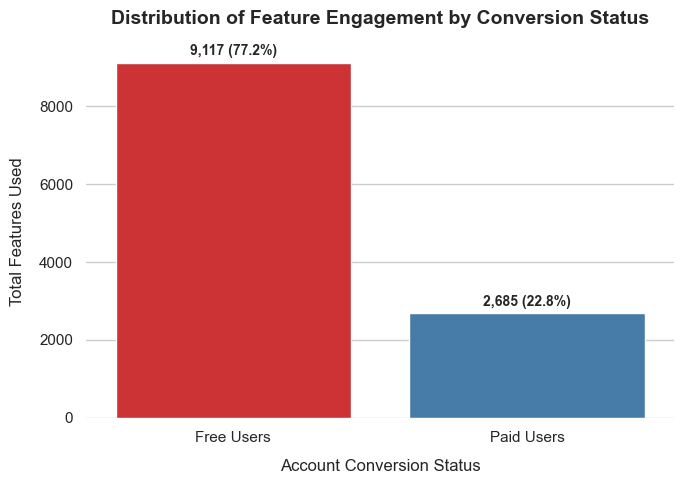

In [20]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=total_feature_usage, 
    x='converted_to_paid', 
    y='feature_usage_count', 
    palette='Set1',
    hue='converted_to_paid', 
    legend=False
)
plt.title('Distribution of Feature Engagement by Conversion Status', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Account Conversion Status', fontsize=12, labelpad=10)
plt.ylabel('Total Features Used', fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1], labels=['Free Users', 'Paid Users'])

for i, bar in enumerate(ax.patches):
    count = total_feature_usage.loc[i, 'feature_usage_count']
    pct = total_feature_usage.loc[i, 'feature_usage_percentage']
    
    ax.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar.get_height() + (total_feature_usage['feature_usage_count'].sum() * 0.01), 
        s=f"{int(count):,} ({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [21]:
query5 = '''
WITH trial_dates AS (
    SELECT 
        account_id,
        MIN(start_date) AS trial_start_date
    FROM subscriptions
    WHERE is_trial = 1
    GROUP BY account_id
)
SELECT 
    f.feature_name,
    COUNT(DISTINCT CASE WHEN m.converted_to_paid = 1 THEN m.account_id END) AS paid_converters_count,
    COUNT(DISTINCT CASE WHEN m.converted_to_paid = 0 THEN m.account_id END) AS non_converters_count,
    ROUND(SUM(CASE WHEN m.converted_to_paid = 0 THEN f.usage_count ELSE 0 END), 0) AS total_clicks_by_churned_users,
    ROUND(AVG(CASE WHEN m.converted_to_paid = 0 THEN f.usage_duration_secs / 60.0 ELSE NULL END), 2) AS avg_mins_spent_by_churned_users
FROM feature_usage AS f
INNER JOIN subscriptions AS s ON f.subscription_id = s.subscription_id
INNER JOIN master_analytics AS m ON s.account_id = m.account_id
INNER JOIN trial_dates AS t ON m.account_id = t.account_id
WHERE f.usage_date >= t.trial_start_date 
  AND f.usage_date <= DATE_ADD(t.trial_start_date, INTERVAL 7 DAY)
GROUP BY f.feature_name
ORDER BY avg_mins_spent_by_churned_users DESC
LIMIT 10;
'''

feature_trap = pd.read_sql(query5, con=engine)
display(feature_trap)

,feature_name,paid_converters_count,non_converters_count,total_clicks_by_churned_users,avg_mins_spent_by_churned_users
0,feature_16,2,1,13.0,127.83
1,feature_18,5,2,26.0,115.97
2,feature_20,2,4,49.0,82.99
3,feature_15,3,2,22.0,80.42
4,feature_25,5,3,31.0,74.41
5,feature_6,2,4,39.0,70.95
6,feature_10,1,2,24.0,70.93
7,feature_14,1,3,40.0,68.93
8,feature_26,2,4,36.0,66.78
9,feature_35,2,4,43.0,62.43


In [22]:
# Formulating & Testing the "Free Trial Trap" Hypothesis
converters = master_analytics[master_analytics['converted_to_paid'] == 1]
non_converters = master_analytics[master_analytics['converted_to_paid'] == 0]

# --- Mann-Whitney U Test for Total Clicks ---
u_stat_clicks, p_val_clicks = stats.mannwhitneyu(
    non_converters['total_clicks'],
    converters['total_clicks'],
    alternative='two-sided'
)

# --- Mann-Whitney U Test for Total Active Duration (Minutes) ---
u_stat_dur, p_val_dur = stats.mannwhitneyu(
    non_converters['total_duration_mins'],
    converters['total_duration_mins'],
    alternative='two-sided'
)

print("---- Mann-Whitney U Test: Total Clicks ----")
print(f"U-statistic: {u_stat_clicks:.4f}")
print(f"P-value: {p_val_clicks:.4f}")
print(f"Non-Converters Median Clicks: {non_converters['total_clicks'].median():.1f}")
print(f"Converters Median Clicks: {converters['total_clicks'].median():.1f}")

print("\n---- Mann-Whitney U Test: Total Active Duration (Minutes) ----")
print(f"U-statistic: {u_stat_dur:.4f}")
print(f"P-value: {p_val_dur:.4f}")
print(f"Non-Converters Median Duration: {non_converters['total_duration_mins'].median():.1f}")
print(f"Converters Median Duration: {converters['total_duration_mins'].median():.1f}")
print("\n------------------------------------------------")


if p_val_clicks < 0.05 and p_val_dur < 0.05:
    # Check if non-converters actually have higher medians (or means) than converters
    if (non_converters['total_clicks'].median() > converters['total_clicks'].median() and 
        non_converters['total_duration_mins'].median() > converters['total_duration_mins'].median()):
        
        print("Hypothesis Supported! \n"
              "Non-converters exhibit significantly higher early usage intensity (medians) than converters,\n"
              "driven by heavy usage of specific key features (like feature_20).")
    else:
        print("Significant difference found!\n"
              "However, converters have higher overall usage intensity than non-converters.")
else:
    print("Hypothesis Rejected.\n"
          "There is no statistically significant difference in early product usage intensity\n"
          "between users who convert and users who do not convert.")

---- Mann-Whitney U Test: Total Clicks ----
U-statistic: 23304.5000
P-value: 0.0036
Non-Converters Median Clicks: 0.0
Converters Median Clicks: 0.0

---- Mann-Whitney U Test: Total Active Duration (Minutes) ----
U-statistic: 23472.5000
P-value: 0.0054
Non-Converters Median Duration: 0.0
Converters Median Duration: 0.0

------------------------------------------------
Significant difference found!
However, converters have higher overall usage intensity than non-converters.


In [23]:
query6 = '''
SELECT 
    active_days_count,
    COUNT(account_id) as total_accounts,
    SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) as successful_conversions,
    ROUND((SUM(converted_to_paid) * 100 / COUNT(account_id)), 2) as conversion_rate_pct
FROM master_analytics
GROUP BY active_days_count
ORDER BY active_days_count ASC;
'''

active_day_conversion = pd.read_sql(query6, con=engine)
display(active_day_conversion)

,active_days_count,total_accounts,successful_conversions,conversion_rate_pct
0,0,327,88.0,26.91
1,1,130,53.0,40.77
2,2,35,14.0,40.00
3,3,7,3.0,42.86
4,4,1,0.0,0.00


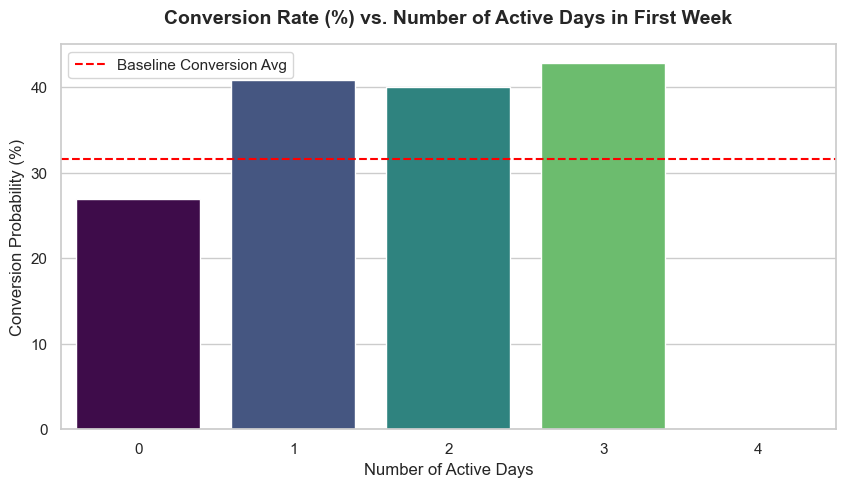

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=active_day_conversion, x='active_days_count', y='conversion_rate_pct', palette='viridis', hue='active_days_count', legend=False)
plt.axhline(y=master_analytics['converted_to_paid'].mean()*100, color='red', linestyle='--', label='Baseline Conversion Avg')
plt.title('Conversion Rate (%) vs. Number of Active Days in First Week', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Active Days')
plt.ylabel('Conversion Probability (%)')
plt.legend()
plt.show()

In [25]:
# Formulating & Testing the "Week Usage Difference" Hypothesis
query_week_usage = """
WITH trial_subscriptions AS (
    SELECT 
        account_id,
        subscription_id,
        MIN(start_date) OVER(PARTITION BY account_id) AS trial_start_date
    FROM subscriptions
    WHERE is_trial = 1
)
SELECT 
    m.account_id,
    COALESCE(SUM(CASE WHEN DATEDIFF(f.usage_date, t.trial_start_date) BETWEEN 0 AND 6 THEN f.usage_count ELSE 0 END), 0) AS week1_clicks,
    COALESCE(SUM(CASE WHEN DATEDIFF(f.usage_date, t.trial_start_date) BETWEEN 7 AND 13 THEN f.usage_count ELSE 0 END), 0) AS week2_clicks
FROM master_analytics m
LEFT JOIN trial_subscriptions t 
    ON m.account_id = t.account_id
LEFT JOIN feature_usage f 
    ON t.subscription_id = f.subscription_id
WHERE m.converted_to_paid = 0
GROUP BY m.account_id;
"""

df_week_usage = pd.read_sql(query_week_usage, con=engine)

# Paired T-Test
t_stat, p_val = stats.ttest_rel(
    df_week_usage['week1_clicks'], 
    df_week_usage['week2_clicks']
)

print("--- Paired T-Test: Week 1 Clicks vs Week 2 Clicks ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")
print("\n------------------------------------------------------------")

if p_val < 0.05:
    if t_stat > 0:
        print("Hypothesis Supported! \n"
              "There is a statistically significant drop-off in user engagement.\n"
              "Non-converting users are heavily active in Week 1, but their usage\n"
              "reduced significantly by Week 2.")
    else:
        print("Significant difference found, \n"
              "However, non-converting users actually have higher usage in Week 2 than in Week 1.")
else:
    print("Hypothesis Rejected.\n"
          "There is no statistically significant difference in engagement (clicks)\n"
          "between Week 1 and Week 2 for non-converting users.")

--- Paired T-Test: Week 1 Clicks vs Week 2 Clicks ---
T-Statistic: 0.0581
P-Value: 0.9537

------------------------------------------------------------
Hypothesis Rejected.
There is no statistically significant difference in engagement (clicks)
between Week 1 and Week 2 for non-converting users.


- Time and clicks directly correlate with trial success. If a user spends under 20 minutes in the app, they are at high risk of dropping off.
- Non-converters use the product heavily during their 14 days to extract free value (Account for 9,117 usage events (77.25%)) and then walking away without paying once the trial expires.
- Moving a user from 0 to even 1 or 2 features increases their conversion probability by over 13.6 percentage points (from ~27% to ~41%).
- feature_20 has the highest engagement among non-converters in both clicks and duration (49.0 clicks, 82.99 mins duration) indicates that they extract massive amount of value from it.
- Statistical test proves that users who convert interact with the product significantly more than those who drop off, even though the medians for both groups are 0.0 (because a huge portion of trialists in both groups sign up and barely click anything)

Onboarding Problems & Customer Support Questions

In [26]:
query7 ='''
    SELECT 
        total_errors_encountered,
        COUNT(account_id) AS total_accounts,
        SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) AS successful_conversions,
        ROUND(SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) / COUNT(account_id) * 100, 2) AS conversion_rate_pct
    FROM master_analytics
    GROUP BY total_errors_encountered
    ORDER BY total_errors_encountered ASC;
'''
errors_vs_conversion = pd.read_sql_query(query7, con=engine)
print("--- Error Count vs Conversion Rate ---")
display(errors_vs_conversion)

--- Error Count vs Conversion Rate ---


,total_errors_encountered,total_accounts,successful_conversions,conversion_rate_pct
0,0,439,131.0,29.84
1,1,28,10.0,35.71
2,2,22,12.0,54.55
3,3,7,3.0,42.86
4,4,1,1.0,100.00
5,5,2,1.0,50.00
6,7,1,0.0,0.00


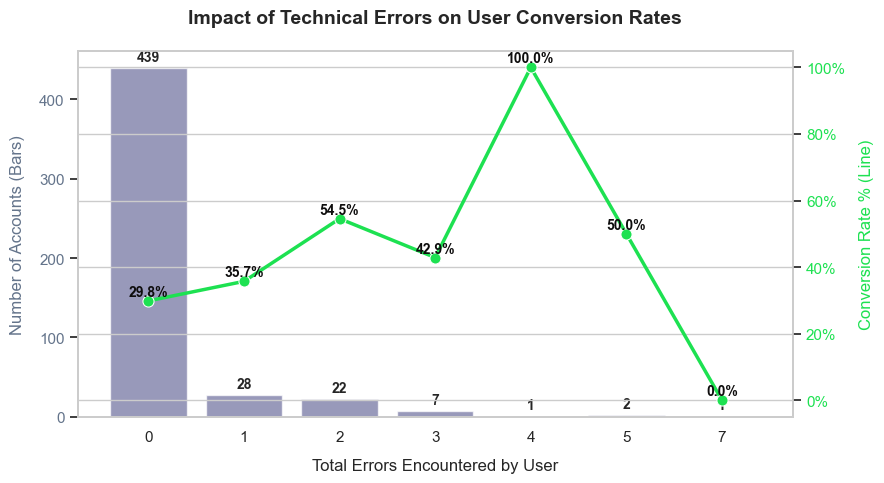

In [27]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=errors_vs_conversion,
    x='total_errors_encountered',
    y='total_accounts',
    color="#6467a5",
    alpha=0.7,
    ax=ax1
)

ax1.set_title('Impact of Technical Errors on User Conversion Rates', fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Total Errors Encountered by User', fontsize=12, labelpad=10)
ax1.set_ylabel('Number of Accounts (Bars)', fontsize=12, labelpad=10, color='#64748b')
ax1.tick_params(axis='y', labelcolor='#64748b')
ax1.grid(False)

for i, bar in enumerate(ax1.patches):
    count = errors_vs_conversion.loc[i, 'total_accounts']
    
    ax1.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar.get_height() + (errors_vs_conversion['total_accounts'].sum() * 0.01), 
        s=f"{int(count):,}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


ax2 = ax1.twinx()

sns.lineplot(
    data=errors_vs_conversion,
    x=range(len(errors_vs_conversion)),
    y='conversion_rate_pct',
    color='#1de151',
    linewidth=2.5,
    marker='o',
    markersize=8,
    ax=ax2
)


ax2.set_ylabel('Conversion Rate % (Line)', fontsize=12, labelpad=10, color="#1de151")
ax2.tick_params(axis='y', labelcolor='#1de151')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

for i, row in errors_vs_conversion.iterrows():
    ax2.text(
        x=i,
        y=row['conversion_rate_pct'] + 1.5,
        s=f"{row['conversion_rate_pct']:.1f}%",
        color="#0e0d0d",
        fontweight='bold',
        fontsize=10,
        ha='center'
    )

plt.tight_layout()
plt.show()

In [28]:
query8 = '''
WITH trial_dates AS (
    SELECT 
        account_id,
        subscription_id,
        MIN(start_date) OVER(PARTITION BY account_id) AS trial_start_date
    FROM subscriptions
    WHERE is_trial = 1
)
SELECT 
    f.is_beta_feature,
    COUNT(*) AS total_usage_events_7d,
    SUM(f.error_count) AS cumulative_errors_encountered_7d,
    COUNT(DISTINCT CASE WHEN f.error_count > 0 THEN f.subscription_id END) AS unique_impacted_subscriptions_7d
FROM feature_usage f
INNER JOIN trial_dates t 
    ON f.subscription_id = t.subscription_id
WHERE DATEDIFF(f.usage_date, t.trial_start_date) BETWEEN 0 AND 6
GROUP BY f.is_beta_feature;
'''

beta_responsible_errors_7d = pd.read_sql(query8, con=engine)
print("--- Error Breakdown: Core vs. Beta Features (First 7 Days of Trial) ---")
display(beta_responsible_errors_7d)

--- Error Breakdown: Core vs. Beta Features (First 7 Days of Trial) ---


,is_beta_feature,total_usage_events_7d,cumulative_errors_encountered_7d,unique_impacted_subscriptions_7d
0,0,33,6.0,4
1,1,3,0.0,0


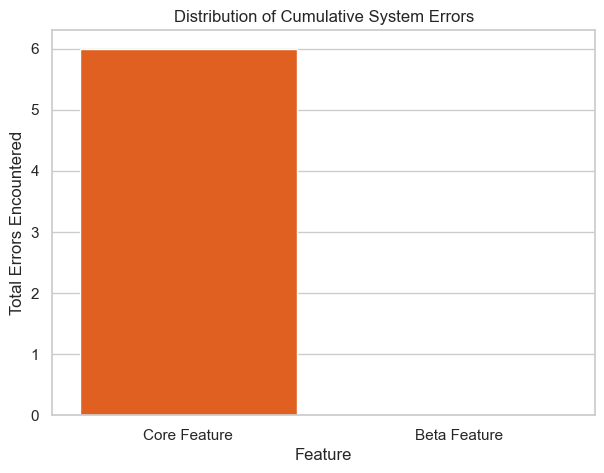

In [29]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=beta_responsible_errors_7d, 
    x='is_beta_feature', 
    y='cumulative_errors_encountered_7d', 
    palette='autumn',
    hue='is_beta_feature',
    legend=False
)
plt.title('Distribution of Cumulative System Errors')
plt.ylabel('Total Errors Encountered')
plt.xlabel('Feature')
plt.xticks([0, 1], ['Core Feature', 'Beta Feature'])
plt.show()

In [30]:
# Formulating & Testing the "Friction Threshold" Hypothesis
converters_errors = master_analytics[master_analytics['converted_to_paid'] == 1]['total_errors_encountered']
non_converters_errors = master_analytics[master_analytics['converted_to_paid'] == 0]['total_errors_encountered']

print("\n--- Mann-Whitney U Test ---")
u_stat, p_val_u = stats.mannwhitneyu(
    non_converters_errors, 
    converters_errors, 
    alternative='two-sided'
)
print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value: {p_val_u:.4f}")
print("\n------------------------------------------------------------")

if p_val_u < 0.05:
    if non_converters_errors.mean() > converters_errors.mean():
        print("Hypothesis Supported! \n"
              "We reject H0. Error density is a statistically significant driver of customer drop-off.\n"
              "Technical problem during the trial directly leads a user's likelihood to convert.")
    else:
        print("Significant difference found, \n"
              "However, converters unexpectedly encountered more errors than non-converters.")
else:
    print("Hypothesis rejected. \n"
          "Early technical glitches are not the primary reason people abandon the trial.")


--- Mann-Whitney U Test ---
U-Statistic: 25025.5000
P-Value: 0.0196

------------------------------------------------------------
Significant difference found, 
However, converters unexpectedly encountered more errors than non-converters.


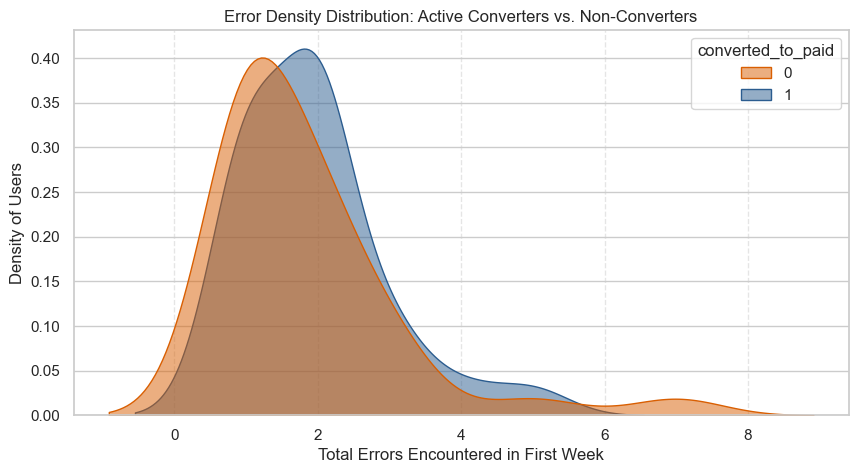

In [31]:
active_users_df = master_analytics[master_analytics['total_errors_encountered'] > 0]

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=active_users_df, 
    x='total_errors_encountered', 
    hue='converted_to_paid', 
    fill=True, 
    common_norm=False, 
    palette=['#d95f02', '#2b5c8f'], 
    alpha=0.5
)
plt.title("Error Density Distribution: Active Converters vs. Non-Converters")
plt.xlabel("Total Errors Encountered in First Week")
plt.ylabel("Density of Users")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

- Accounts that encounter errors actually convert at a higher rate than accounts with zero errors, because high-intent power users explore the product deeply during their trial, so they ignore minor bugs and see the product's value. 
- Data shows that beta features are not responsible for early trial churn or onboarding errors.
- Statistical testing (Mann-Whitney U, P = 0.0196) proved that errors in our dataset were a proxy for high engagement—serious buyers were exploring the product deeply enough to trigger bugs, whereas churned users simply logged off before ever hitting a technical error.

In [32]:
query9 = '''
    SELECT
        tickets_raised_count,
        COUNT(account_id) AS total_users,
        SUM(CASE WHEN converted_to_paid = 0 THEN 1 ELSE 0 END) AS dropped_off,
        ROUND(SUM(CASE WHEN converted_to_paid = 0 THEN 1 ELSE 0 END) / COUNT(account_id) * 100 ,2) AS dropped_off_pct
    FROM master_analytics
    WHERE tickets_raised_count > 0
    GROUP BY tickets_raised_count
    ORDER BY tickets_raised_count ASC;
'''
ticket_volume = pd.read_sql_query(query9, con=engine)
display(ticket_volume)

,tickets_raised_count,total_users,dropped_off,dropped_off_pct
0,1,34,28.0,82.35
1,2,1,0.0,0.00


In [33]:
query10 = '''
    SELECT 
        CASE 
            WHEN s.resolution_time_hours > 48 THEN 'Delayed (>48 Hours)'
            ELSE 'Resolved Promptly (<=48 Hours)'
        END AS resolution_speed,
        COUNT(DISTINCT m.account_id) AS total_accounts,
        COUNT(DISTINCT CASE WHEN m.converted_to_paid = 1 THEN m.account_id END) AS successful_conversions,
        ROUND(
            (COUNT(DISTINCT CASE WHEN m.converted_to_paid = 1 THEN m.account_id END) * 100.0) 
            / COUNT(DISTINCT m.account_id), 
            2
        ) AS conversion_rate_pct

    FROM master_analytics AS m
    INNER JOIN support_tickets AS s ON s.account_id = m.account_id
    GROUP BY resolution_speed
'''

ticket_closed_at = pd.read_sql_query(query10, con=engine)
display(ticket_closed_at)

,resolution_speed,total_accounts,successful_conversions,conversion_rate_pct
0,Delayed (>48 Hours),215,54,25.12
1,Resolved Promptly (<=48 Hours),319,73,22.88


In [34]:
# Formulating & Testing the "Tickets Raised Dropped Off" Hypothesis

support_users = master_analytics[master_analytics['tickets_raised_count'] > 0].copy()

converters_response = support_users[support_users['converted_to_paid'] == 1]['avg_response_time_mins']
non_converters_response = support_users[support_users['converted_to_paid'] == 0]['avg_response_time_mins']

print(f"Number of active support users who converted: {len(converters_response)}")
print(f"Number of active support users who dropped off: {len(non_converters_response)}")

print("\n--- Mann-Whitney U Test ---")
u_stat, p_val_u = stats.mannwhitneyu(
    non_converters_response,     # Testing if non-converters have greater delays
    converters_response, 
    alternative='greater'
)
print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value: {p_val_u:.4f}")
print("\n------------------------------------------------------------")

median_non_conv = non_converters_response.median()
median_conv = converters_response.median()

if p_val_u < 0.05:
    print("Hypothesis Supported! \n"
          "Support response delay is a statistically significant driver of trial abandonment.\n"
          f"Users who churned waited significantly longer (Median: {median_non_conv:.1f} mins) \n"
          f"than users who successfully converted (Median: {median_conv:.1f} mins).")
else:
    print("Hypothesis Rejected. \n"
          "Support response delays are not statistically greater for non-converters.\n"
          "Conversion drop-offs are likely driven by product pricing rather than support delays.")

Number of active support users who converted: 7
Number of active support users who dropped off: 28

--- Mann-Whitney U Test ---
U-Statistic: 115.5000
P-Value: 0.2416

------------------------------------------------------------
Hypothesis Rejected. 
Support response delays are not statistically greater for non-converters.
Conversion drop-offs are likely driven by product pricing rather than support delays.


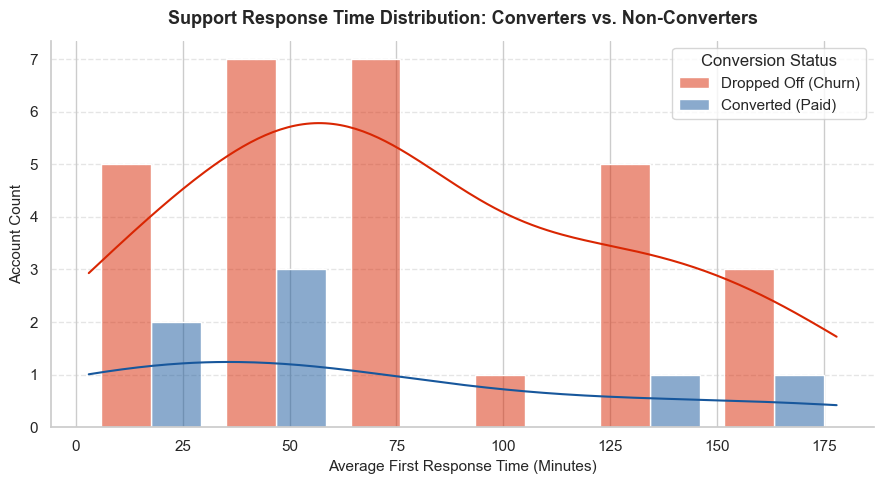

In [35]:
support_users = master_analytics[master_analytics['tickets_raised_count'] > 0].copy()

support_users['Conversion Status'] = support_users['converted_to_paid'].map({
    0: 'Dropped Off (Churn)',
    1: 'Converted (Paid)'
})

plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=support_users, 
    x='avg_response_time_mins', 
    hue='Conversion Status', 
    hue_order=['Dropped Off (Churn)', 'Converted (Paid)'],
    palette={'Dropped Off (Churn)': '#d92602', 'Converted (Paid)': '#17579c'},
    kde=True, 
    multiple='dodge', 
    bins=6,           
    shrink=0.8      
)

plt.title("Support Response Time Distribution: Converters vs. Non-Converters", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Average First Response Time (Minutes)", fontsize=11)
plt.ylabel("Account Count", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

- Support tickets serve as a strong early warning signal for churn: 82.35% of users who raised a support ticket failed to convert.
- Statistical testing shows that support response time was not the bottleneck causing users to leave. Users churned regardless of how fast or slow support replied, indicating that friction was driven by fundamental product issues (like pricing or feature complexity) rather than support responsiveness

In [36]:
query11 = '''
SELECT 
    ROUND(avg_csat_score, 0) as rounded_csat,
    COUNT(account_id) as total_users,
    SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) AS successful_conversions,
    ROUND(SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) / COUNT(account_id) * 100, 2) as conversion_rate_pct
FROM master_analytics
WHERE avg_csat_score != -1 -- Ignore accounts with no score
GROUP BY rounded_csat
ORDER BY rounded_csat DESC;
'''

csat_effect = pd.read_sql(query11, con=engine)
display(csat_effect)

,rounded_csat,total_users,successful_conversions,conversion_rate_pct
0,5.0,2,0.0,0.00
1,4.0,9,2.0,22.22
2,3.0,14,2.0,14.29


In [37]:
response_support = master_analytics[(master_analytics['tickets_raised_count'] > 0) & (master_analytics['avg_csat_score'] != -1)].copy()

# Pearson Correlation Test
r_val, p_val = stats.pearsonr(response_support['avg_response_time_mins'], response_support['avg_csat_score'])

print("--- Correlation Test: Response Delay vs. CSAT Rating ---")
print(f"Pearson r coefficient: {r_val:.4f}")
print(f"P-Value: {p_val:.4f}")

--- Correlation Test: Response Delay vs. CSAT Rating ---
Pearson r coefficient: -0.0717
P-Value: 0.7336


In [38]:
# Formulating & Testing the "Skipped Survey Dropped-Off" Hypothesis
skipped_survey = master_analytics[master_analytics['tickets_raised_count'] > 0].copy()
skipped_survey['ignored_any_survey'] = skipped_survey['skipped_surveys_count'] > 0

contingency_table = pd.crosstab(skipped_survey['ignored_any_survey'], skipped_survey['converted_to_paid'])
print("--- Contingency Table (Actual Counts) ---")
display(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print("\n------------------------------------------------------------")

if p < 0.05:
    print("Hypothesis Supported! \n" 
          "Skipping support surveys is a statistically significant early warning sign of product abandonment.")
else:
    print("Hypothesis Rejected. \n" 
          "There is no statistically significant relationship between survey avoidance and conversion.")

--- Contingency Table (Actual Counts) ---


converted_to_paid,0,1
ignored_any_survey,,
False,21,4
True,7,3



--- Chi-Square Test Results ---
Chi-Square Statistic: 0.2188
P-Value: 0.6400

------------------------------------------------------------
Hypothesis Rejected. 
There is no statistically significant relationship between survey avoidance and conversion.


- Customer satisfaction (CSAT) scores on support tickets do not predict whether a trial user will buy, the 2 users who gave a perfect 5.0 CSAT rating 0% converted. This shows that having a great customer support interaction doesn't overcome underlying product churn drivers like pricing or missing core features.
- Pearson Correlation Test shows that, a slight delay in first response time does not drive down CSAT scores, nor does a faster response automatically guarantee higher ratings.
- A Chi-Square test of independence ($\chi^2 = 0.2188, p = 0.6400$) confirmed no statistically significant relationship between survey engagement and trial conversion.

Marketing & User Segmentation Questions

In [39]:
query12 = '''
    SELECT
        referral_source,
        COUNT(account_id) AS total_signups,
        SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) AS successful_conversions,
        ROUND(SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) / COUNT(account_id) * 100, 2) AS conversion_rate_pct
    FROM master_analytics
    GROUP BY referral_source
    ORDER BY total_signups DESC;
'''
refer_from = pd.read_sql_query(query12, con = engine)
display(refer_from)

,referral_source,total_signups,successful_conversions,conversion_rate_pct
0,organic,114,45.0,39.47
1,other,103,29.0,28.16
2,ads,98,36.0,36.73
3,event,96,25.0,26.04
4,partner,89,23.0,25.84


In [40]:
query13 = """
SELECT 
    industry,
    plan_tier,
    COUNT(account_id) as total_accounts,
    SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) AS successful_conversions,
    ROUND(SUM(CASE WHEN converted_to_paid = 1 THEN 1 ELSE 0 END) / COUNT(account_id) * 100, 2) AS conversion_rate_pct
FROM master_analytics
GROUP BY industry, plan_tier
ORDER BY industry ASC, total_accounts DESC;
"""

industry_tier = pd.read_sql_query(query13, con=engine)
print("\n--- Industry & Plan Tier Breakdown ---")
display(industry_tier)


--- Industry & Plan Tier Breakdown ---


,industry,plan_tier,total_accounts,successful_conversions,conversion_rate_pct
0,Cybersecurity,Pro,38,8.0,21.05
1,Cybersecurity,Basic,31,10.0,32.26
2,Cybersecurity,Enterprise,31,10.0,32.26
3,DevTools,Pro,42,10.0,23.81
4,DevTools,Basic,36,16.0,44.44
5,DevTools,Enterprise,35,10.0,28.57
6,EdTech,Basic,28,15.0,53.57
7,EdTech,Pro,27,10.0,37.04
8,EdTech,Enterprise,24,5.0,20.83
9,FinTech,Pro,41,16.0,39.02


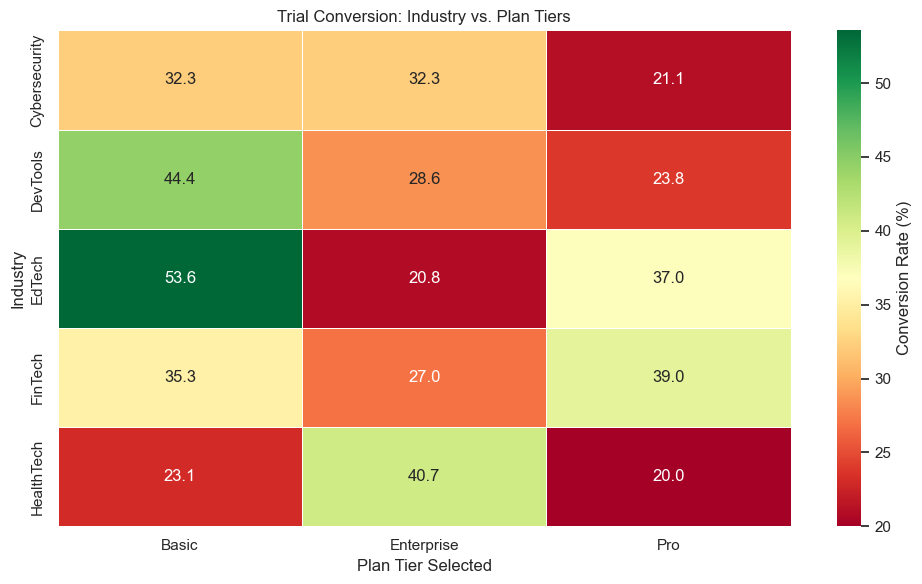

In [41]:
pivot_matrix = industry_tier.pivot(
    index='industry', 
    columns='plan_tier', 
    values='conversion_rate_pct'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_matrix, 
    annot=True, 
    cmap='RdYlGn', 
    fmt=".1f", 
    cbar_kws={'label': 'Conversion Rate (%)'},
    linewidths=0.5
)
plt.title("Trial Conversion: Industry vs. Plan Tiers")
plt.ylabel("Industry")
plt.xlabel("Plan Tier Selected")
plt.tight_layout()
plt.show()

- Users who find the product naturally (Organic) or through targeted Ads have high intent and convert best.
- The Basic plan is the primary driver of trial-to-paid success across most industries (especially EdTech at 53.57%). However, the Pro tier consistently underperforms across DevTools, Cybersecurity, and HealthTech—suggesting its pricing or feature packaging is awkwardly positioned between Basic and Enterprise.

#### **Recommendations**
- Trigger automated email and in-app push notifications, contextual tooltips, and banner announcements when an account registers zero active clicks within 24 hours of signing up.
- Build guided walkthroughs that force new users to interact with at least 2 core features during their first login to cross the 20-minute engagement milestone.
- Invest in contextual in-app guidance, embedding instant AI chatbots, and fixing core product bugs so users never hit blockers that force them to submit a ticket.
- Place usage limits on high-utility features like feature_20 and feature_18. Allow 3–5 free uses before requiring a paid upgrade, converting high-usage non-converters into paying subscribers.
- Restructure the Pro plan's features and price point to create a clearer bridge between Basic and Enterprise.
- Shift marketing budget away from events and partnerships (which suffer ~28% churn) toward high-intent Organic and Paid Search channels.